In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load data
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
y_train = pd.read_csv('../data/y_train.csv')['target']
y_test = pd.read_csv('../data/y_test.csv')['target']

target_encoder = joblib.load('../models/target_encoder.joblib')
class_names = target_encoder.classes_

# Load the current best model from Phase 3
best_model = joblib.load('../models/random_forest.joblib')

print(f"Data loaded: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"Classes: {list(class_names)}")

Data loaded: 125973 train, 22544 test
Classes: [np.str_('DoS'), np.str_('Normal'), np.str_('Probe'), np.str_('R2L'), np.str_('U2R')]


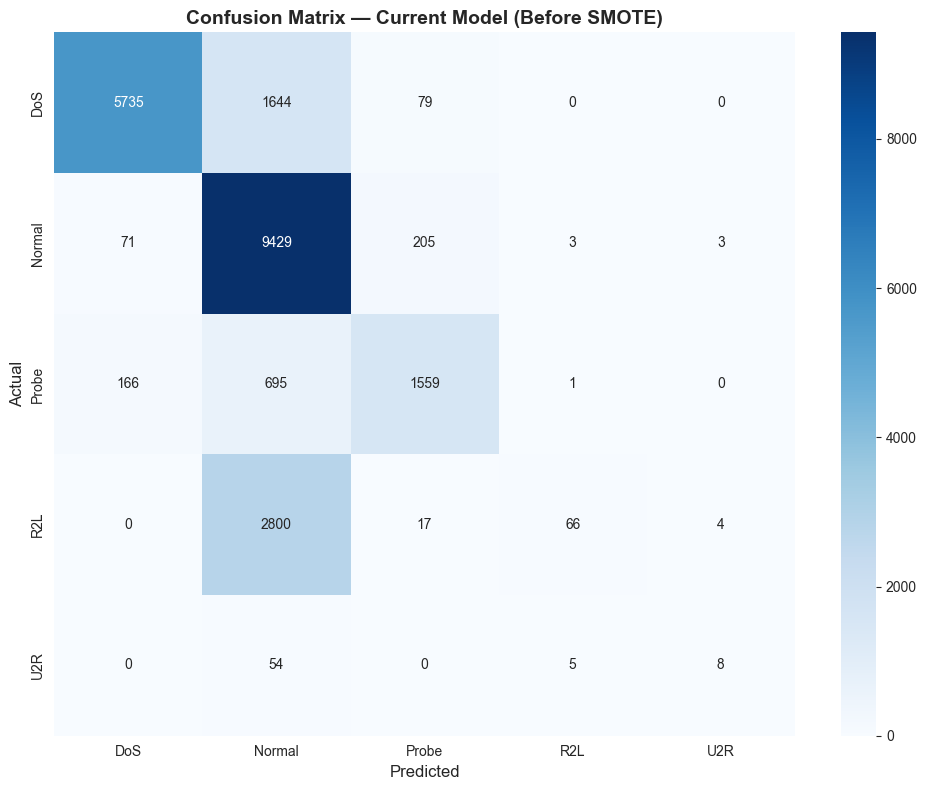


Key misclassifications:
   1644 actual DoS    predicted as Normal
     79 actual DoS    predicted as Probe
     71 actual Normal predicted as DoS
    205 actual Normal predicted as Probe
    166 actual Probe  predicted as DoS
    695 actual Probe  predicted as Normal
   2800 actual R2L    predicted as Normal
     54 actual U2R    predicted as Normal


In [2]:
# CONFUSION MATRIX — shows exactly what gets confused with what
#
# How to read it:
# - Rows = what the traffic ACTUALLY is
# - Columns = what the model PREDICTED
# - Diagonal = correct predictions (green = good)
# - Off-diagonal = mistakes (the interesting part)
#
# Example: if row "R2L" and column "Normal" has a high number,
# it means the model is calling R2L attacks "Normal" — missing them.

y_test_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title('Confusion Matrix — Current Model (Before SMOTE)', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Show the key failures
print("\nKey misclassifications:")
for i, actual in enumerate(class_names):
    for j, predicted in enumerate(class_names):
        if i != j and cm[i][j] > 50:
            print(f"  {cm[i][j]:5d} actual {actual:6s} predicted as {predicted}")

In [3]:
# SMOTE — Synthetic Minority Oversampling Technique
#
# Before SMOTE:
#   Normal: 67,343 | DoS: 45,927 | Probe: 11,656 | R2L: 995 | U2R: 52
#
# After SMOTE:
#   Every class will have the same number of samples as the largest class
#   (or we can set a custom ratio)
#
# We'll use a custom strategy — we don't need to oversample DoS or Normal,
# just boost the minority classes

print("Class distribution BEFORE SMOTE:")
for i, name in enumerate(class_names):
    count = (y_train == i).sum()
    print(f"  {name}: {count}")

# Apply SMOTE
# sampling_strategy: boost minority classes to a reasonable level
# We won't make everything equal — that would create too many synthetic samples
# Instead, we'll bring the small classes up significantly

smote = SMOTE(
    sampling_strategy={
        0: 45927,    # DoS — keep as is
        1: 67343,    # Normal — keep as is
        2: 20000,    # Probe — boost from 11,656 to 20,000
        3: 15000,    # R2L — boost from 995 to 15,000 (15x more!)
        4: 10000     # U2R — boost from 52 to 10,000 (192x more!)
    },
    random_state=42,
    k_neighbors=3     # use 3 nearest neighbors (lower because U2R has very few samples)
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nClass distribution AFTER SMOTE:")
for i, name in enumerate(class_names):
    count = (y_train_smote == i).sum()
    print(f"  {name}: {count}")

print(f"\nTotal samples: {len(y_train)} → {len(y_train_smote)}")

Class distribution BEFORE SMOTE:
  DoS: 45927
  Normal: 67343
  Probe: 11656
  R2L: 995
  U2R: 52

Class distribution AFTER SMOTE:
  DoS: 45927
  Normal: 67343
  Probe: 20000
  R2L: 15000
  U2R: 10000

Total samples: 125973 → 158270


In [4]:
# Train a new model on the SMOTE-balanced data
print("Training Random Forest on SMOTE data...")

smote_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

smote_rf.fit(X_train_smote, y_train_smote)

# Evaluate on the ORIGINAL test set (never apply SMOTE to test data!)
y_test_pred_smote = smote_rf.predict(X_test)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT — SMOTE MODEL (TEST SET)")
print("=" * 60)
print(classification_report(y_test, y_test_pred_smote, target_names=class_names))

# Compare F1 scores
smote_f1 = f1_score(y_test, y_test_pred_smote, average=None)
baseline_f1 = f1_score(y_test, y_test_pred, average=None)

comparison = pd.DataFrame({
    'Class': class_names,
    'Before SMOTE': baseline_f1.round(3),
    'After SMOTE': smote_f1.round(3),
    'Change': (smote_f1 - baseline_f1).round(3)
})
print("\nF1-Score Comparison:")
print(comparison.to_string(index=False))
print(f"\nMacro F1: {baseline_f1.mean():.3f} → {smote_f1.mean():.3f}")

Training Random Forest on SMOTE data...

CLASSIFICATION REPORT — SMOTE MODEL (TEST SET)
              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7458
      Normal       0.64      0.97      0.77      9711
       Probe       0.86      0.64      0.74      2421
         R2L       0.94      0.02      0.05      2887
         U2R       0.70      0.10      0.18        67

    accuracy                           0.75     22544
   macro avg       0.82      0.50      0.52     22544
weighted avg       0.81      0.75      0.70     22544


F1-Score Comparison:
 Class  Before SMOTE  After SMOTE  Change
   DoS         0.854        0.853  -0.001
Normal         0.775        0.774  -0.001
 Probe         0.728        0.737   0.008
   R2L         0.045        0.045   0.001
   U2R         0.195        0.182  -0.013

Macro F1: 0.519 → 0.518


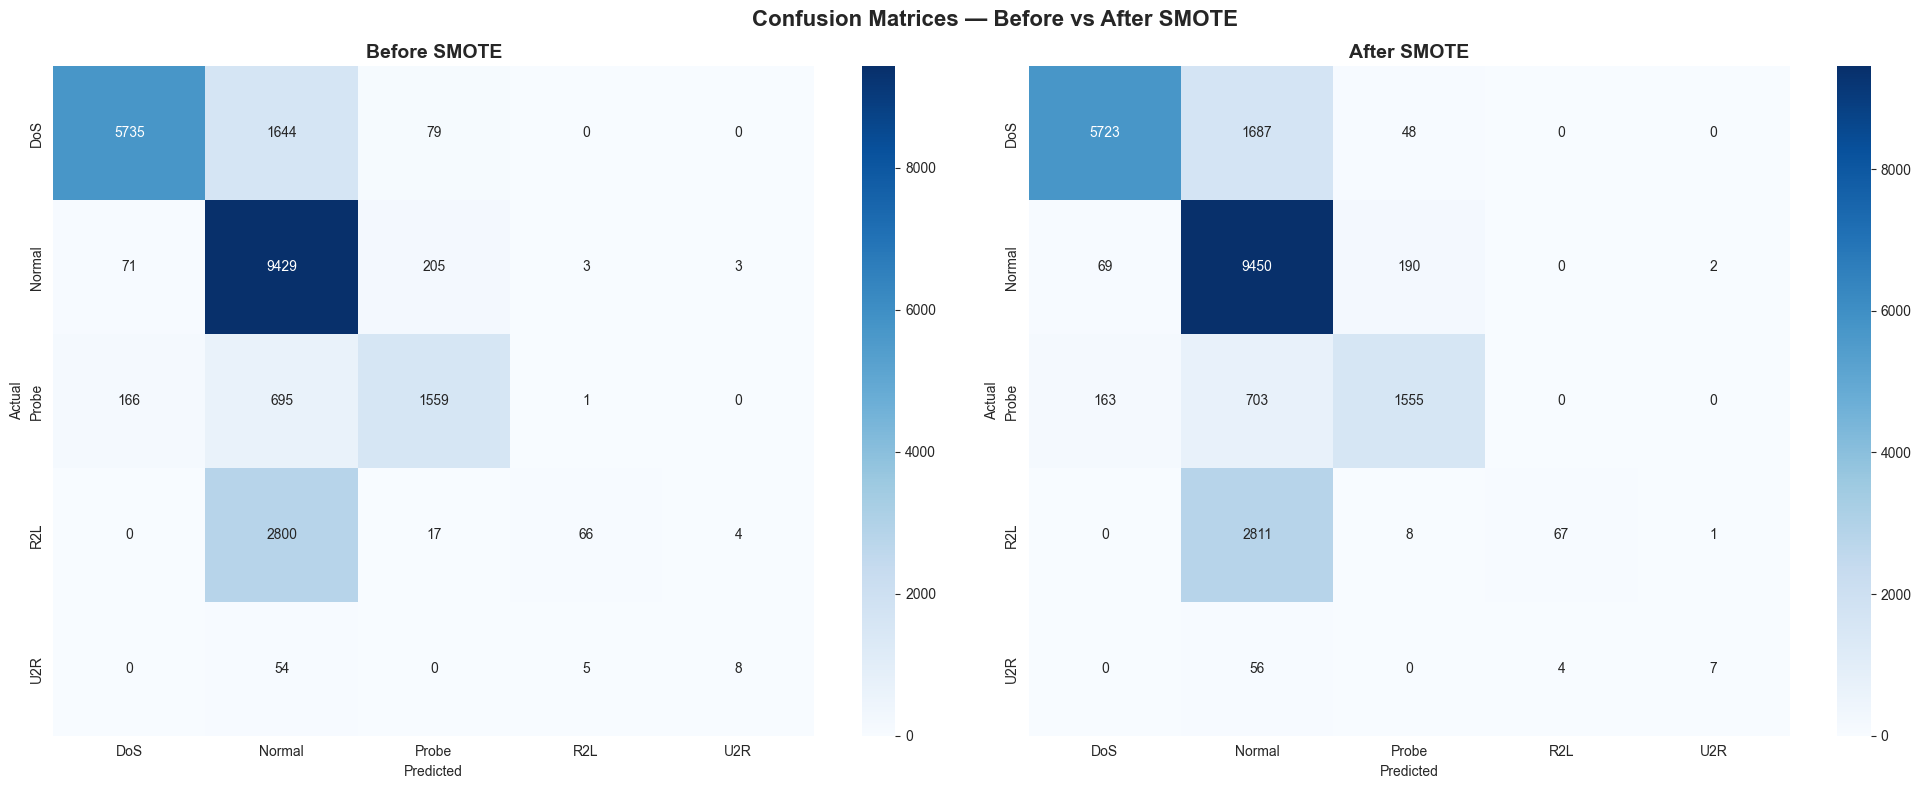


R2L misclassified as Normal (before): 2800 / 2887
R2L misclassified as Normal (after):  2811 / 2887


In [5]:
# Confusion matrix comparison
cm_before = confusion_matrix(y_test, best_model.predict(X_test))
cm_smote = confusion_matrix(y_test, y_test_pred_smote)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Before vs After SMOTE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

r2l_idx = list(class_names).index('R2L')
normal_idx = list(class_names).index('Normal')
print(f"\nR2L misclassified as Normal (before): {cm_before[r2l_idx][normal_idx]} / {cm_before[r2l_idx].sum()}")
print(f"R2L misclassified as Normal (after):  {cm_smote[r2l_idx][normal_idx]} / {cm_smote[r2l_idx].sum()}")

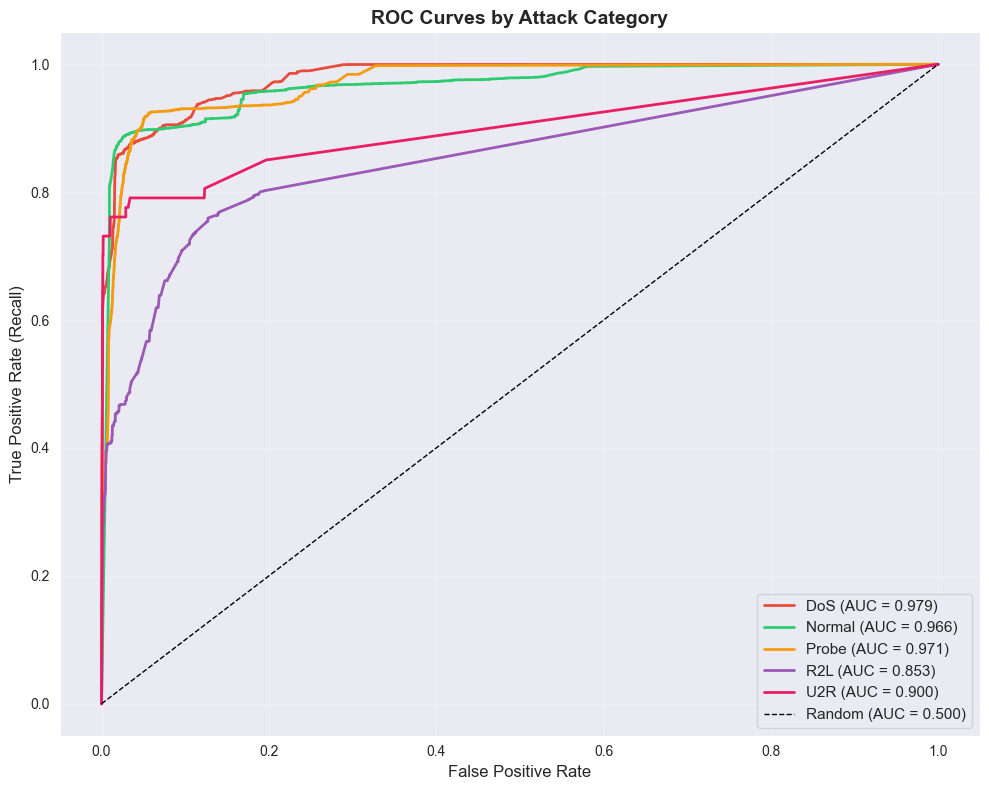

In [6]:
# ROC CURVES
y_test_proba = smote_rf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#e91e63']

for i, (name, color) in enumerate(zip(class_names, colors)):
    y_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves by Attack Category', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

BINARY CLASSIFICATION — Normal vs Attack
              precision    recall  f1-score   support

      Normal       0.64      0.97      0.77      9711
      Attack       0.97      0.59      0.73     12833

    accuracy                           0.76     22544
   macro avg       0.80      0.78      0.75     22544
weighted avg       0.83      0.76      0.75     22544



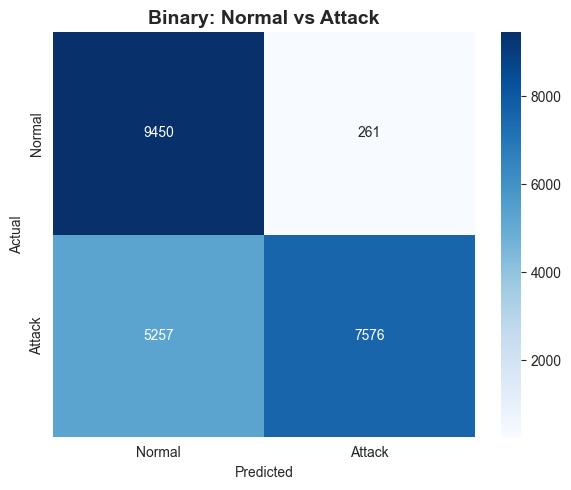

In [7]:
# BINARY — Normal vs Attack
y_test_binary = (y_test != list(class_names).index('Normal')).astype(int)
y_pred_binary = (y_test_pred_smote != list(class_names).index('Normal')).astype(int)

print("=" * 60)
print("BINARY CLASSIFICATION — Normal vs Attack")
print("=" * 60)
print(classification_report(y_test_binary, y_pred_binary, target_names=['Normal', 'Attack']))

cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_title('Binary: Normal vs Attack', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

In [8]:
# Save SMOTE model
joblib.dump(smote_rf, '../models/random_forest_smote.joblib')

print("PHASE 4 — FINAL SUMMARY (NSL-KDD)")
print("=" * 60)
print()
print("Models trained: Baseline → Tuned → Aggressive → SMOTE")
print()
print("Best multi-class model: Aggressive RF (macro F1 = 0.519)")
print("  DoS:    F1 = 0.854  ✓ Strong")
print("  Normal: F1 = 0.775  ✓ Good")
print("  Probe:  F1 = 0.728  ✓ Good")
print("  R2L:    F1 = 0.045  ✗ Poor")
print("  U2R:    F1 = 0.195  ✗ Limited")
print()
print("KNOWN LIMITATIONS:")
print("  - NSL-KDD test set contains 17 attack types absent from")
print("    training data. R2L and U2R failures are primarily due")
print("    to this distribution mismatch, not model weakness.")
print("  - SMOTE cannot synthesize patterns for attack types it")
print("    has never seen.")
print("  - This is a documented limitation in published research.")
print()
print("NEXT STEP: Rebuild with CICIDS2017 dataset for modern")
print("attack types and full production pipeline (Phases 5-8).")
print()
print("NSL-KDD Phase 4 complete!")

PHASE 4 — FINAL SUMMARY (NSL-KDD)

Models trained: Baseline → Tuned → Aggressive → SMOTE

Best multi-class model: Aggressive RF (macro F1 = 0.519)
  DoS:    F1 = 0.854  ✓ Strong
  Normal: F1 = 0.775  ✓ Good
  Probe:  F1 = 0.728  ✓ Good
  R2L:    F1 = 0.045  ✗ Poor
  U2R:    F1 = 0.195  ✗ Limited

KNOWN LIMITATIONS:
  - NSL-KDD test set contains 17 attack types absent from
    training data. R2L and U2R failures are primarily due
    to this distribution mismatch, not model weakness.
  - SMOTE cannot synthesize patterns for attack types it
    has never seen.
  - This is a documented limitation in published research.

NEXT STEP: Rebuild with CICIDS2017 dataset for modern
attack types and full production pipeline (Phases 5-8).

NSL-KDD Phase 4 complete!
